## **Image Classification using `sklearn.svm`**
Image files used are from https://github.com/Abhishek-Arora/Image-Classification-Using-SVM



**Try other ML algorithms for classsification and compare the performance**


### Image Classification using SVM

This notebook demonstrates how to perform image classification using Support Vector Machines (SVM) in scikit-learn.

**The main goal is to build a model that can accurately classify images into different categories.**

The notebook covers the following tasks:

1. **Loading and Preprocessing Image Data:** Images are loaded from a structured directory and preprocessed to a consistent size.
2. **Splitting Data into Training and Testing Sets:** The dataset is split to evaluate the model's performance on unseen data.
3. **Training an SVM Classifier with Parameter Optimization:** An SVM classifier is trained, and its hyperparameters are tuned using GridSearchCV to find the best configuration.
4. **Making Predictions:** The trained model is used to predict the categories of images in the testing set.
5. **Evaluating Model Performance:** The performance of the classifier is assessed using a classification report, which provides metrics such as precision, recall, and F1-score.

### By the end of this exercise, you will have a working image classification model and understand how to evaluate its performance.

### **Try other ML algorithms for classsification and compare the performance**

In [1]:
!pip install gitpython --quiet # Install the library to clone git repos

import git

# Clone the repository
repo_url = 'https://github.com/Abhishek-Arora/Image-Classification-Using-SVM.git'
repo_dir = 'Image-Classification-Using-SVM'
git.Repo.clone_from(repo_url, repo_dir, branch='master')

# Update the image_folder path
image_folder = "Image-Classification-Using-SVM/images"  # New path to the image folder

In [13]:
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
#%matplotlib notebook
%matplotlib inline
from sklearn import svm, metrics, datasets
from sklearn.utils import Bunch
from sklearn.model_selection import GridSearchCV, train_test_split

from skimage.io import imread
from skimage.transform import resize
import skimage.io # Import the skimage module

In [2]:
import os

image_folder = "C:/GitHub/Colab-git-demo-tep/images"  # Path to the image folder
categories = os.listdir(image_folder)  # Get the list of categories

for category in categories:
  category_path = os.path.join(image_folder, category)
  for image_file in os.listdir(category_path):
    image_path = os.path.join(category_path, image_file)
    # Process the image file (e.g., read using OpenCV or Pillow)

In [3]:
# import os

# image_folder = "/content/Image-Classification-Using-SVM/images"  # Path to the image folder
# C:\GitHub\Colab-git-demo-tep\images
# categories = os.listdir(image_folder)  # Get the list of categories

# for category in categories:
#   category_path = os.path.join(image_folder, category)
#   for image_file in os.listdir(category_path):
#     image_path = os.path.join(category_path, image_file)
#     # Process the image file (e.g., read using OpenCV or Pillow)

### Load images in structured directory like it's sklearn sample dataset

In [4]:
def load_image_files(container_path, dimension=(64, 64)):
    """
    Load image files with categories as subfolder names
    which performs like scikit-learn sample dataset

    Parameters
    ----------
    container_path : string or unicode
        Path to the main folder holding one subfolder per category
    dimension : tuple
        size to which image are adjusted to

    Returns
    -------
    Bunch
    """
    image_dir = Path(container_path)
    folders = [directory for directory in image_dir.iterdir() if directory.is_dir()]
    categories = [fo.name for fo in folders]

    descr = "A image classification dataset"
    images = []
    flat_data = []
    target = []
    for i, direc in enumerate(folders):
        for file in direc.iterdir():
            img = skimage.io.imread(file)
            img_resized = resize(img, dimension, anti_aliasing=True, mode='reflect')
            flat_data.append(img_resized.flatten())
            images.append(img_resized)
            target.append(i)
    flat_data = np.array(flat_data)
    target = np.array(target)
    images = np.array(images)

    return Bunch(data=flat_data,
                 target=target,
                 target_names=categories,
                 images=images,
                 DESCR=descr)

In [5]:
# Update the path to where your images are located
image_dataset = load_image_files("C:/GitHub/Colab-git-demo-tep/images/")

### Split data

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    image_dataset.data, image_dataset.target, test_size=0.3,random_state=109)

### Train data with parameter optimization

In [7]:
param_grid = [
  {'C': [1, 10, 100, 1000], 'kernel': ['linear']},
  {'C': [1, 10, 100, 1000], 'gamma': [0.001, 0.0001], 'kernel': ['rbf']},
 ]
svc = svm.SVC()
clf = GridSearchCV(svc, param_grid)
clf.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",SVC()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","[{'C': [1, 10, ...], 'kernel': ['linear']}, {'C': [1, 10, ...], 'gamma': [0.001, 0.0001], 'kernel': ['rbf']}]"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",None
,"verbose verbose: int, default=0Controls 

### Predict

In [8]:
y_pred = clf.predict(X_test)

### Report

In [9]:
print("Classification report for - \n{}:\n{}\n".format(
    clf, metrics.classification_report(y_test, y_pred)))

Classification report for - 
GridSearchCV(estimator=SVC(),
             param_grid=[{'C': [1, 10, 100, 1000], 'kernel': ['linear']},
                         {'C': [1, 10, 100, 1000], 'gamma': [0.001, 0.0001],
                          'kernel': ['rbf']}]):
              precision    recall  f1-score   support

           0       0.75      0.55      0.63        22
           1       0.87      0.76      0.81        17
           2       0.85      0.79      0.81        14
           3       0.55      0.71      0.62        17
           4       0.85      1.00      0.92        23

    accuracy                           0.76        93
   macro avg       0.77      0.76      0.76        93
weighted avg       0.77      0.76      0.76        93




In [10]:
# Print a detailed classification report (Precision, Recall, F1-Score)
print(metrics.classification_report(y_test, y_pred, target_names=image_dataset.target_names))

              precision    recall  f1-score   support

   dalmatian       0.75      0.55      0.63        22
 dollar_bill       0.87      0.76      0.81        17
       pizza       0.85      0.79      0.81        14
 soccer_ball       0.55      0.71      0.62        17
   sunflower       0.85      1.00      0.92        23

    accuracy                           0.76        93
   macro avg       0.77      0.76      0.76        93
weighted avg       0.77      0.76      0.76        93



In [ ]:
## Testing on sample Image

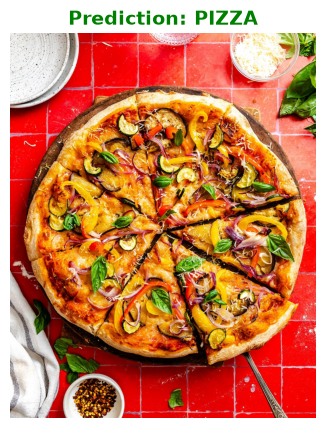

In [14]:
import matplotlib.pyplot as plt
import skimage.io
from skimage.transform import resize
import numpy as np

# 1. Define the path to your test image
# Make sure to replace this with your actual file name!
sample_image_path = "Pizza_test.jpg" 

try:
    # 2. Read and preprocess the single image
    img = skimage.io.imread(sample_image_path)
    
    # Resize to the exact dimension your model expects (64x64)
    # The training function uses anti_aliasing=True and mode='reflect'
    img_resized = resize(img, (64, 64), anti_aliasing=True, mode='reflect')
    
    # 3. Flatten the image to create a 1D vector of features
    # img_resized.flatten() returns 12,288 numbers
    # We wrap it in an extra array [ ... ] because the model expects a 2D batch of samples
    flattened_image = np.array([img_resized.flatten()])
    
    # 4. Use your trained GridSearch object (clf) to make the prediction
    predicted_index = clf.predict(flattened_image)[0]
    
    # 5. Map the numerical prediction index back to the human-readable text name
    # image_dataset.target_names holds ['dalmatian', 'dollar_bill', 'pizza', ...]
    predicted_category = image_dataset.target_names[predicted_index]
    
    # 6. Display the image and the model's prediction side-by-side
    plt.figure(figsize=(5, 5))
    plt.imshow(img)  # Displays the original un-resized image for clarity
    plt.title(f"Prediction: {predicted_category.upper()}", fontsize=14, color='green', fontweight='bold')
    plt.axis('off')
    plt.show()

except FileNotFoundError:
    print(f"Error: Could not find the file at '{sample_image_path}'. Please check your file name and path.")
except NameError:
    print("Error: Make sure your 'clf' model and 'image_dataset' variables are still loaded in memory.")

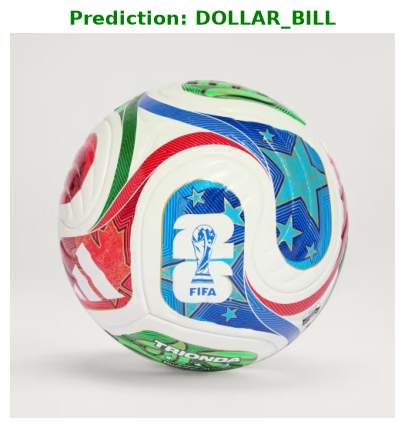

In [18]:
import matplotlib.pyplot as plt
import skimage.io
from skimage.transform import resize
import numpy as np

# 1. Define the path to your test image
# Make sure to replace this with your actual file name!
sample_image_path = "soccer_test21.jpg" 

try:
    # 2. Read and preprocess the single image
    img = skimage.io.imread(sample_image_path)
    
    # Resize to the exact dimension your model expects (64x64)
    # The training function uses anti_aliasing=True and mode='reflect'
    img_resized = resize(img, (64, 64), anti_aliasing=True, mode='reflect')
    
    # 3. Flatten the image to create a 1D vector of features
    # img_resized.flatten() returns 12,288 numbers
    # We wrap it in an extra array [ ... ] because the model expects a 2D batch of samples
    flattened_image = np.array([img_resized.flatten()])
    
    # 4. Use your trained GridSearch object (clf) to make the prediction
    predicted_index = clf.predict(flattened_image)[0]
    
    # 5. Map the numerical prediction index back to the human-readable text name
    # image_dataset.target_names holds ['dalmatian', 'dollar_bill', 'pizza', ...]
    predicted_category = image_dataset.target_names[predicted_index]
    
    # 6. Display the image and the model's prediction side-by-side
    plt.figure(figsize=(5, 5))
    plt.imshow(img)  # Displays the original un-resized image for clarity
    plt.title(f"Prediction: {predicted_category.upper()}", fontsize=14, color='green', fontweight='bold')
    plt.axis('off')
    plt.show()

except FileNotFoundError:
    print(f"Error: Could not find the file at '{sample_image_path}'. Please check your file name and path.")
except NameError:
    print("Error: Make sure your 'clf' model and 'image_dataset' variables are still loaded in memory.")

In [ ]:
'''
The model was not able to recognize this soccer ball.
'''